In [404]:
# Importing required libraries for data handling and visualization

import pandas as pd          # for data manipulation
import numpy as np           # for numerical operations

import matplotlib.pyplot as plt   # for plotting graphs
import seaborn as sns             # for advanced visualization

from sklearn.model_selection import train_test_split    # for splitting the dataset into training and testing sets
from sklearn.preprocessing import StandardScaler        # for feature scaling
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report     # for evaluating the model

In [405]:
df = pd.read_csv("Telco-Customer-Churn.csv")

In [406]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [407]:
# Check number of rows and columns

df.shape

(7043, 21)

In [408]:
# Display all column names

df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [409]:
# Get complete info about dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [410]:
# Check missing values in each column

df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [411]:
# Check duplicate rows

df.duplicated().sum()

np.int64(0)

In [412]:
# Statistical summary of numerical columns

df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [413]:
# Check unique values in target column

df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

#### count plot:

From graph we can say that majority customers not leaving the company

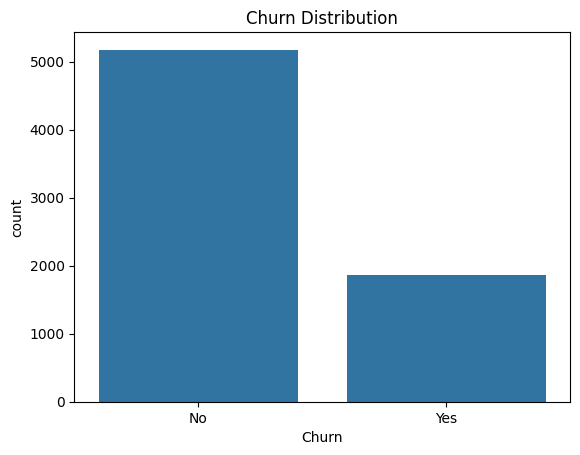

In [414]:
# Count plot for Churn (target variable)
# This shows how many customers stayed vs left

sns.countplot(x='Churn', data=df)

plt.title("Churn Distribution")
plt.show()

#### Gender affects or not:

From graph we can conclude that it doesn't affects on gender  
Also yes ratio is almost same

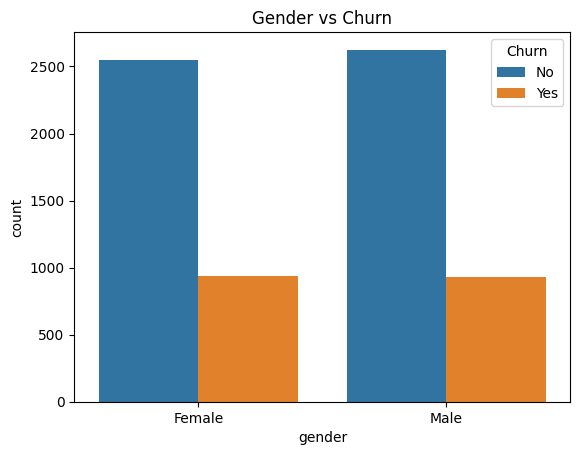

In [415]:
# Check if gender affects churn

sns.countplot(x='gender', hue='Churn', data=df)

plt.title("Gender vs Churn")
plt.show()

#### Check churn based on senior citizen status:

Here we can see that senior citizens are more likely to churn than non-senior citizens.

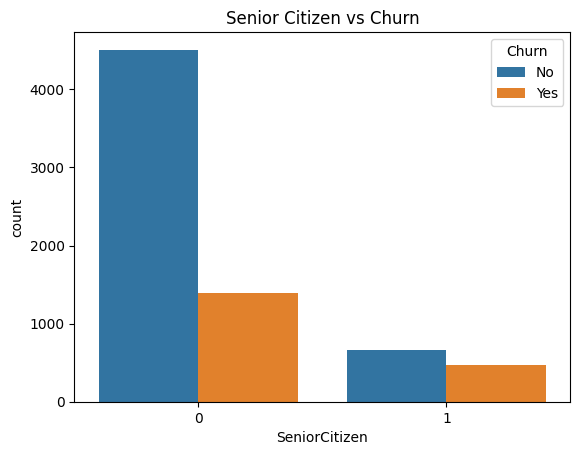

In [416]:
# Check churn based on senior citizen

sns.countplot(x='SeniorCitizen', hue='Churn', data=df)

plt.title("Senior Citizen vs Churn")
plt.show()

#### Contract type vs churn:

Customers with month-to-month contracts are more likely to churn than those with one-year or two-year contracts.  
Short term customers are more likely to churn than long term customers.

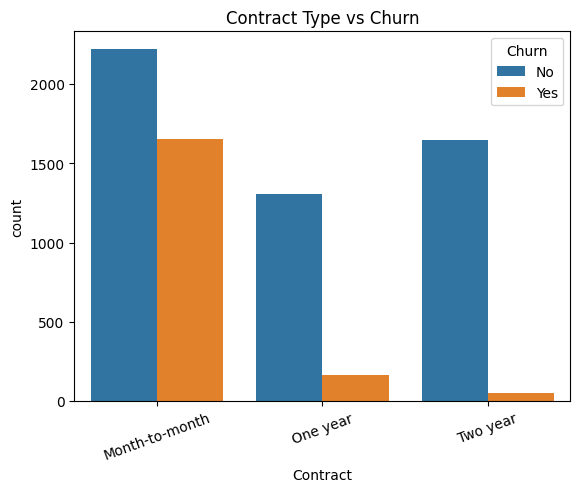

In [417]:
# Analyze churn based on contract type

sns.countplot(x='Contract', hue='Churn', data=df)

plt.title("Contract Type vs Churn")
plt.xticks(rotation=20)
plt.show()

#### Tenure Distribution:

Tenure distribution means how long customers have been with the company.  
The graph shows that most customers have low tenure, meaning many customers are relatively new.  

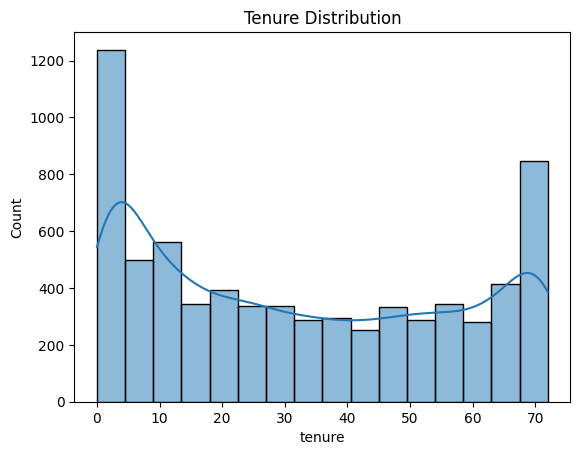

In [418]:
# Distribution of tenure (customer duration)

sns.histplot(df['tenure'], kde=True)

plt.title("Tenure Distribution")
plt.show()

#### Box Plot Analysis:

This graph shows that new customers are more likely to churn than long-term customers.

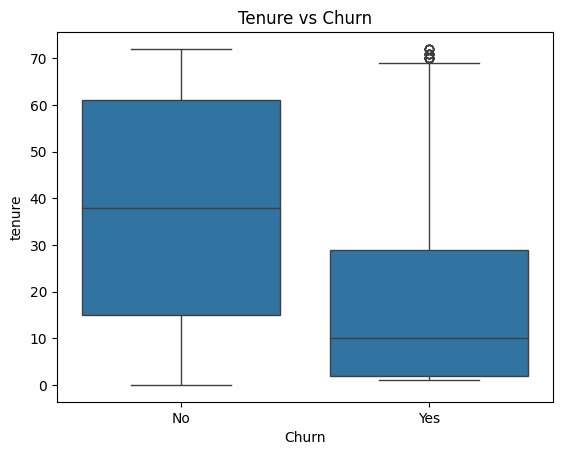

In [419]:
# Boxplot to compare tenure with churn

sns.boxplot(x='Churn', y='tenure', data=df)

plt.title("Tenure vs Churn")
plt.show()

#### Monthly Charges and Churn:

we can see that customers with higher monthly charges tend to churn more.

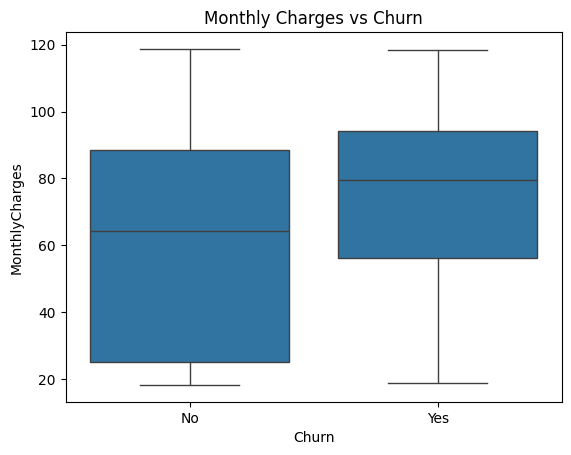

In [420]:
# Compare monthly charges for churn vs non-churn

sns.boxplot(x='Churn', y='MonthlyCharges', data=df)

plt.title("Monthly Charges vs Churn")
plt.show()

#### Heatmap analysis:

Heatmap shows relationships between numerical features, helping in feature selection.
in this heatmap

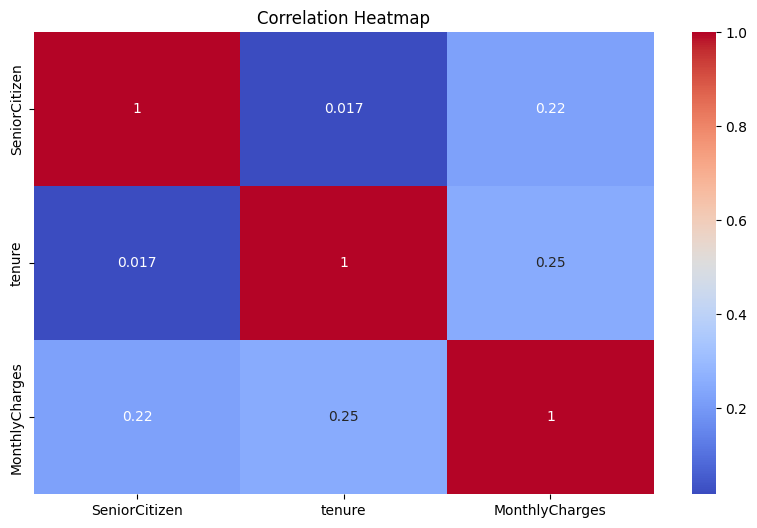

In [421]:
# Correlation between numerical features

plt.figure(figsize=(10,6))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

Heatmap shows relationships between numerical features, helping in feature selection.

In [422]:
# Drop 'customerID' column as it is not useful for prediction
df.drop('customerID', axis=1, inplace=True)

In [423]:
# Convert 'TotalCharges' from string to numeric
# Invalid values will be converted to NaN

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [424]:
# Fill missing values in 'TotalCharges' using median
# here we use median because it is less affected by outliers compared to mean.
# outliers means unusual values that are significantly different from other data points

df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

C:\Users\Vaishnavi Giri\AppData\Local\Temp\ipykernel_15060\3473003203.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


In [425]:
# Convert 'Churn' from Yes/No to 1/0
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [426]:
# Convert categorical variables to numeric using one-hot encoding
# drop_first=True to avoid dummy variable trap (multicollinearity)
#We use drop_first=True to avoid redundant features and multicollinearity.

df = pd.get_dummies(df, drop_first=True)

In [427]:
# Separate input features and target variable
X = df.drop('Churn', axis=1)
y = df['Churn']

In [428]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [429]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# “Scaling is required for distance-based algorithms like KNN and SVM, 
# because they are sensitive to feature magnitude.
# Tree-based models like Decision Tree and Random Forest are not affected by scaling.”

In [430]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)
accuracy_lr = accuracy_score(y_test, y_pred_lr)

print("accuracy:", accuracy_lr)

print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

accuracy: 0.8197303051809794
[[933 103]
 [151 222]]
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.68      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.81      0.82      0.82      1409



In [431]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)
accuracy_knn = accuracy_score(y_test, y_pred_knn)

print("accuracy:", accuracy_knn)

print(confusion_matrix(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

accuracy: 0.7707594038325053
[[892 144]
 [179 194]]
              precision    recall  f1-score   support

           0       0.83      0.86      0.85      1036
           1       0.57      0.52      0.55       373

    accuracy                           0.77      1409
   macro avg       0.70      0.69      0.70      1409
weighted avg       0.76      0.77      0.77      1409



In [432]:
from sklearn.svm import SVC

svm = SVC(kernel='rbf')
svm.fit(X_train_scaled, y_train)

y_pred_svm = svm.predict(X_test_scaled)
accuracy_svm = accuracy_score(y_test, y_pred_svm)

print("accuracy:", accuracy_svm)

print(confusion_matrix(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

accuracy: 0.8140525195173882
[[948  88]
 [174 199]]
              precision    recall  f1-score   support

           0       0.84      0.92      0.88      1036
           1       0.69      0.53      0.60       373

    accuracy                           0.81      1409
   macro avg       0.77      0.72      0.74      1409
weighted avg       0.80      0.81      0.81      1409



In [433]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train_scaled, y_train)

y_pred_nb = nb.predict(X_test_scaled)
accuracy_nb = accuracy_score(y_test, y_pred_nb)

print("accuracy:", accuracy_nb)

print(confusion_matrix(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))

accuracy: 0.6657203690560681
[[605 431]
 [ 40 333]]
              precision    recall  f1-score   support

           0       0.94      0.58      0.72      1036
           1       0.44      0.89      0.59       373

    accuracy                           0.67      1409
   macro avg       0.69      0.74      0.65      1409
weighted avg       0.81      0.67      0.68      1409



In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=5)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
accuracy_dt = accuracy_score(y_test, y_pred_dt)

print("accuracy:", accuracy_dt)

print(confusion_matrix(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

accuracy: 0.8062455642299503
[[964  72]
 [201 172]]
              precision    recall  f1-score   support

           0       0.83      0.93      0.88      1036
           1       0.70      0.46      0.56       373

    accuracy                           0.81      1409
   macro avg       0.77      0.70      0.72      1409
weighted avg       0.80      0.81      0.79      1409



In [435]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("accuracy:", accuracy_rf)

print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

accuracy: 0.7892122072391767
[[941  95]
 [202 171]]
              precision    recall  f1-score   support

           0       0.82      0.91      0.86      1036
           1       0.64      0.46      0.54       373

    accuracy                           0.79      1409
   macro avg       0.73      0.68      0.70      1409
weighted avg       0.78      0.79      0.78      1409



In [436]:
results = {
    "LR": accuracy_lr,
    "KNN": accuracy_knn,
    "SVM": accuracy_svm,
    "NB": accuracy_nb,
    "DT": accuracy_dt,
    "RF": accuracy_rf
}

for k, v in results.items():
    print(k, ":", v)

LR : 0.8197303051809794
KNN : 0.7707594038325053
SVM : 0.8140525195173882
NB : 0.6657203690560681
DT : 0.8062455642299503
RF : 0.7892122072391767


In [437]:
best_model = max(results, key=results.get)
print("Best Model:", best_model)

Best Model: LR


In [438]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [439]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)
df['Cluster'] = clusters

In [440]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

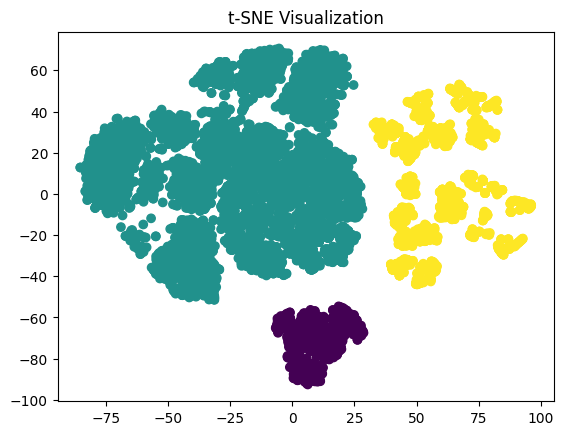

In [441]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

plt.scatter(X_tsne[:,0], X_tsne[:,1], c=df['Cluster'], cmap='viridis')
plt.title("t-SNE Visualization")
plt.show()

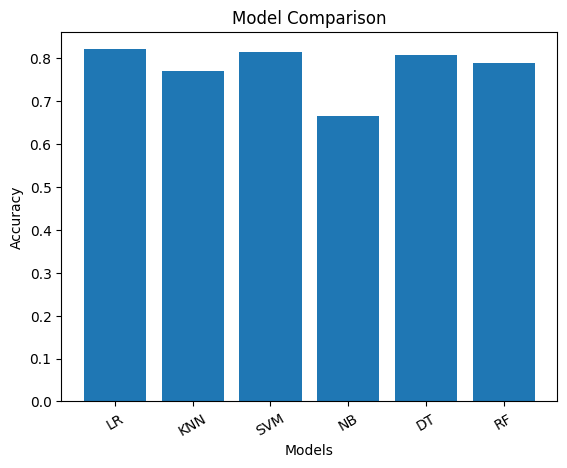

In [442]:
plt.bar(list(results.keys()), list(results.values()))
plt.title("Model Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.xticks(rotation=30)
plt.show()

In [443]:
import pickle

pickle.dump(rf, open("churn_model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))